In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from matplotlib import pyplot as plt
from utils.config import Config
from data_handler import DataHandler
# from classificators.dummy_classifier import DummyClassifier
# from classificators.random_forest_classifier import RandomForestClassifierSK
# from utils.utils import calculate_mcc_multilabel, plot_per_class_confusion

pd.options.display.float_format = '{:.6f}'.format

In [2]:
config = Config()

# Seeding
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

val_mccs = []
test_mccs = []
lr_histories_by_fold = {}

# CuPy check
import cupy as cp
print("CuPy GPU count:", cp.cuda.runtime.getDeviceCount())
print("Using GPU via CuPy")

# load data
datahandler = DataHandler(config=config)

CuPy GPU count: 1
Using GPU via CuPy
Local dataset found: data\cps_data_multi_label.pkl
Loading data into memory...
Data loaded.


In [6]:
fold = 1
val_id = fold + 1 if fold < 4 else 1

datahandler.config.data.test_experiment_id = fold
datahandler.config.data.validation_experiment_id = val_id

(train_x, train_y), (val_x, val_y), (test_x, test_y), final_target_cols = datahandler.get_data_loaders()

print("train_x:", train_x.shape)
print("train_y:", train_y.shape)
print("final_target_cols:", final_target_cols)

Starting data preparation...
train_x: (2136440, 7, 160)
train_y: (2136440, 6)
final_target_cols: ['Driving(curve)', 'Driving(straight)', 'Lifting(lowering)', 'Lifting(raising)', 'Stationary processes', 'Turntable wrapping']


In [ ]:

def adaptive_window_entropy(signal, bins=16):
    signal = np.asarray(signal, dtype=np.float32)
    signal = signal[np.isfinite(signal)]

    if signal.size == 0:
        return np.nan

    smin, smax = signal.min(), signal.max()
    if np.isclose(smin, smax):
        return 0.0

    hist, _ = np.histogram(signal, bins=bins, range=(smin, smax))
    probs = hist.astype(np.float32) / hist.sum()
    probs = probs[probs > 0]

    return -np.sum(probs * np.log2(probs))

subset_size = 2136440
bins = 16
batch_size = 50000

sensor_names = datahandler.config.data.sensor_cols
n_samples = min(subset_size, train_x.shape[0])
n_sensors = train_x.shape[1]
seq_len = train_x.shape[2]

window_entropy = np.zeros((n_samples, n_sensors), dtype=np.float32)

for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    X_batch = train_x[start:end].astype(np.float32, copy=False)

    X_gpu = cp.asarray(X_batch, dtype=cp.float32)  # (B, 7, 160)

    x_min = X_gpu.min(axis=2, keepdims=True)
    x_max = X_gpu.max(axis=2, keepdims=True)
    x_range = x_max - x_min

    valid = x_range > 0

    scaled = cp.where(valid, (X_gpu - x_min) / x_range, 0.0)
    bin_idx = cp.floor(scaled * bins).astype(cp.int32)
    bin_idx = cp.clip(bin_idx, 0, bins - 1)

    bin_ids = cp.arange(bins, dtype=cp.int32)
    counts = (bin_idx[..., None] == bin_ids).sum(axis=2).astype(cp.float32)   # (B, 7, bins)

    probs = counts / seq_len
    entropy_gpu = -cp.sum(cp.where(probs > 0, probs * cp.log2(probs), 0.0), axis=2)
    entropy_gpu = cp.where(valid.squeeze(-1), entropy_gpu, 0.0)

    window_entropy[start:end] = cp.asnumpy(entropy_gpu).astype(np.float32)

    del X_gpu, x_min, x_max, x_range, valid, scaled, bin_idx, counts, probs, entropy_gpu
    cp.get_default_memory_pool().free_all_blocks()

window_entropy_df = pd.DataFrame(window_entropy, columns=sensor_names)S
window_entropy_df.head()

,Acc.x,Acc.y,Acc.z,Gyro.x,Gyro.y,Gyro.z,Baro.x
0,3.802356,3.509836,1.777412,3.345899,3.494305,3.439229,3.937514
1,3.807940,3.509836,1.776180,3.346802,3.489004,3.446496,3.943568
2,3.802789,3.511263,1.777412,3.349068,3.482343,3.462526,3.938417
3,3.795377,3.507727,1.778369,3.346802,3.478556,3.454356,3.945292
4,3.795377,3.510827,1.778369,3.346802,3.474813,3.449593,3.950936


In [11]:
summary_df = pd.DataFrame({
    "sensor": sensor_names,
    "mean_entropy": window_entropy_df.mean().values,
    "median_entropy": window_entropy_df.median().values,
    "std_entropy": window_entropy_df.std().values,
    "min_entropy": window_entropy_df.min().values,
    "max_entropy": window_entropy_df.max().values
}).sort_values("mean_entropy", ascending=False).reset_index(drop=True)

summary_df

,sensor,mean_entropy,median_entropy,std_entropy,min_entropy,max_entropy
0,Baro.x,3.748477,3.930201,0.533826,0.000000,4.000000
1,Acc.x,3.604073,3.635557,0.228658,0.109445,3.979059
2,Acc.y,3.584982,3.615909,0.245451,0.054751,3.987008
3,Gyro.y,3.578662,3.607210,0.237377,0.164081,3.980656
4,Gyro.x,3.555206,3.575068,0.242354,0.109445,3.978155
5,Gyro.z,3.539707,3.546890,0.239754,0.164081,3.992756
6,Acc.z,2.973609,3.431145,0.808773,0.109445,3.979728


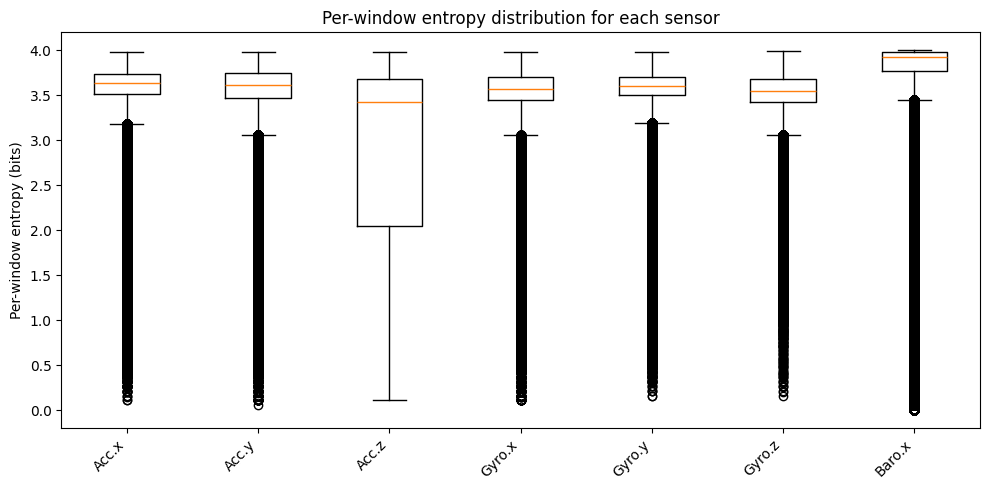

In [12]:
plt.figure(figsize=(10, 5))
plt.boxplot([window_entropy_df[col].values for col in sensor_names], tick_labels=sensor_names)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Per-window entropy (bits)")
plt.title("Per-window entropy distribution for each sensor")
plt.tight_layout()
plt.show()

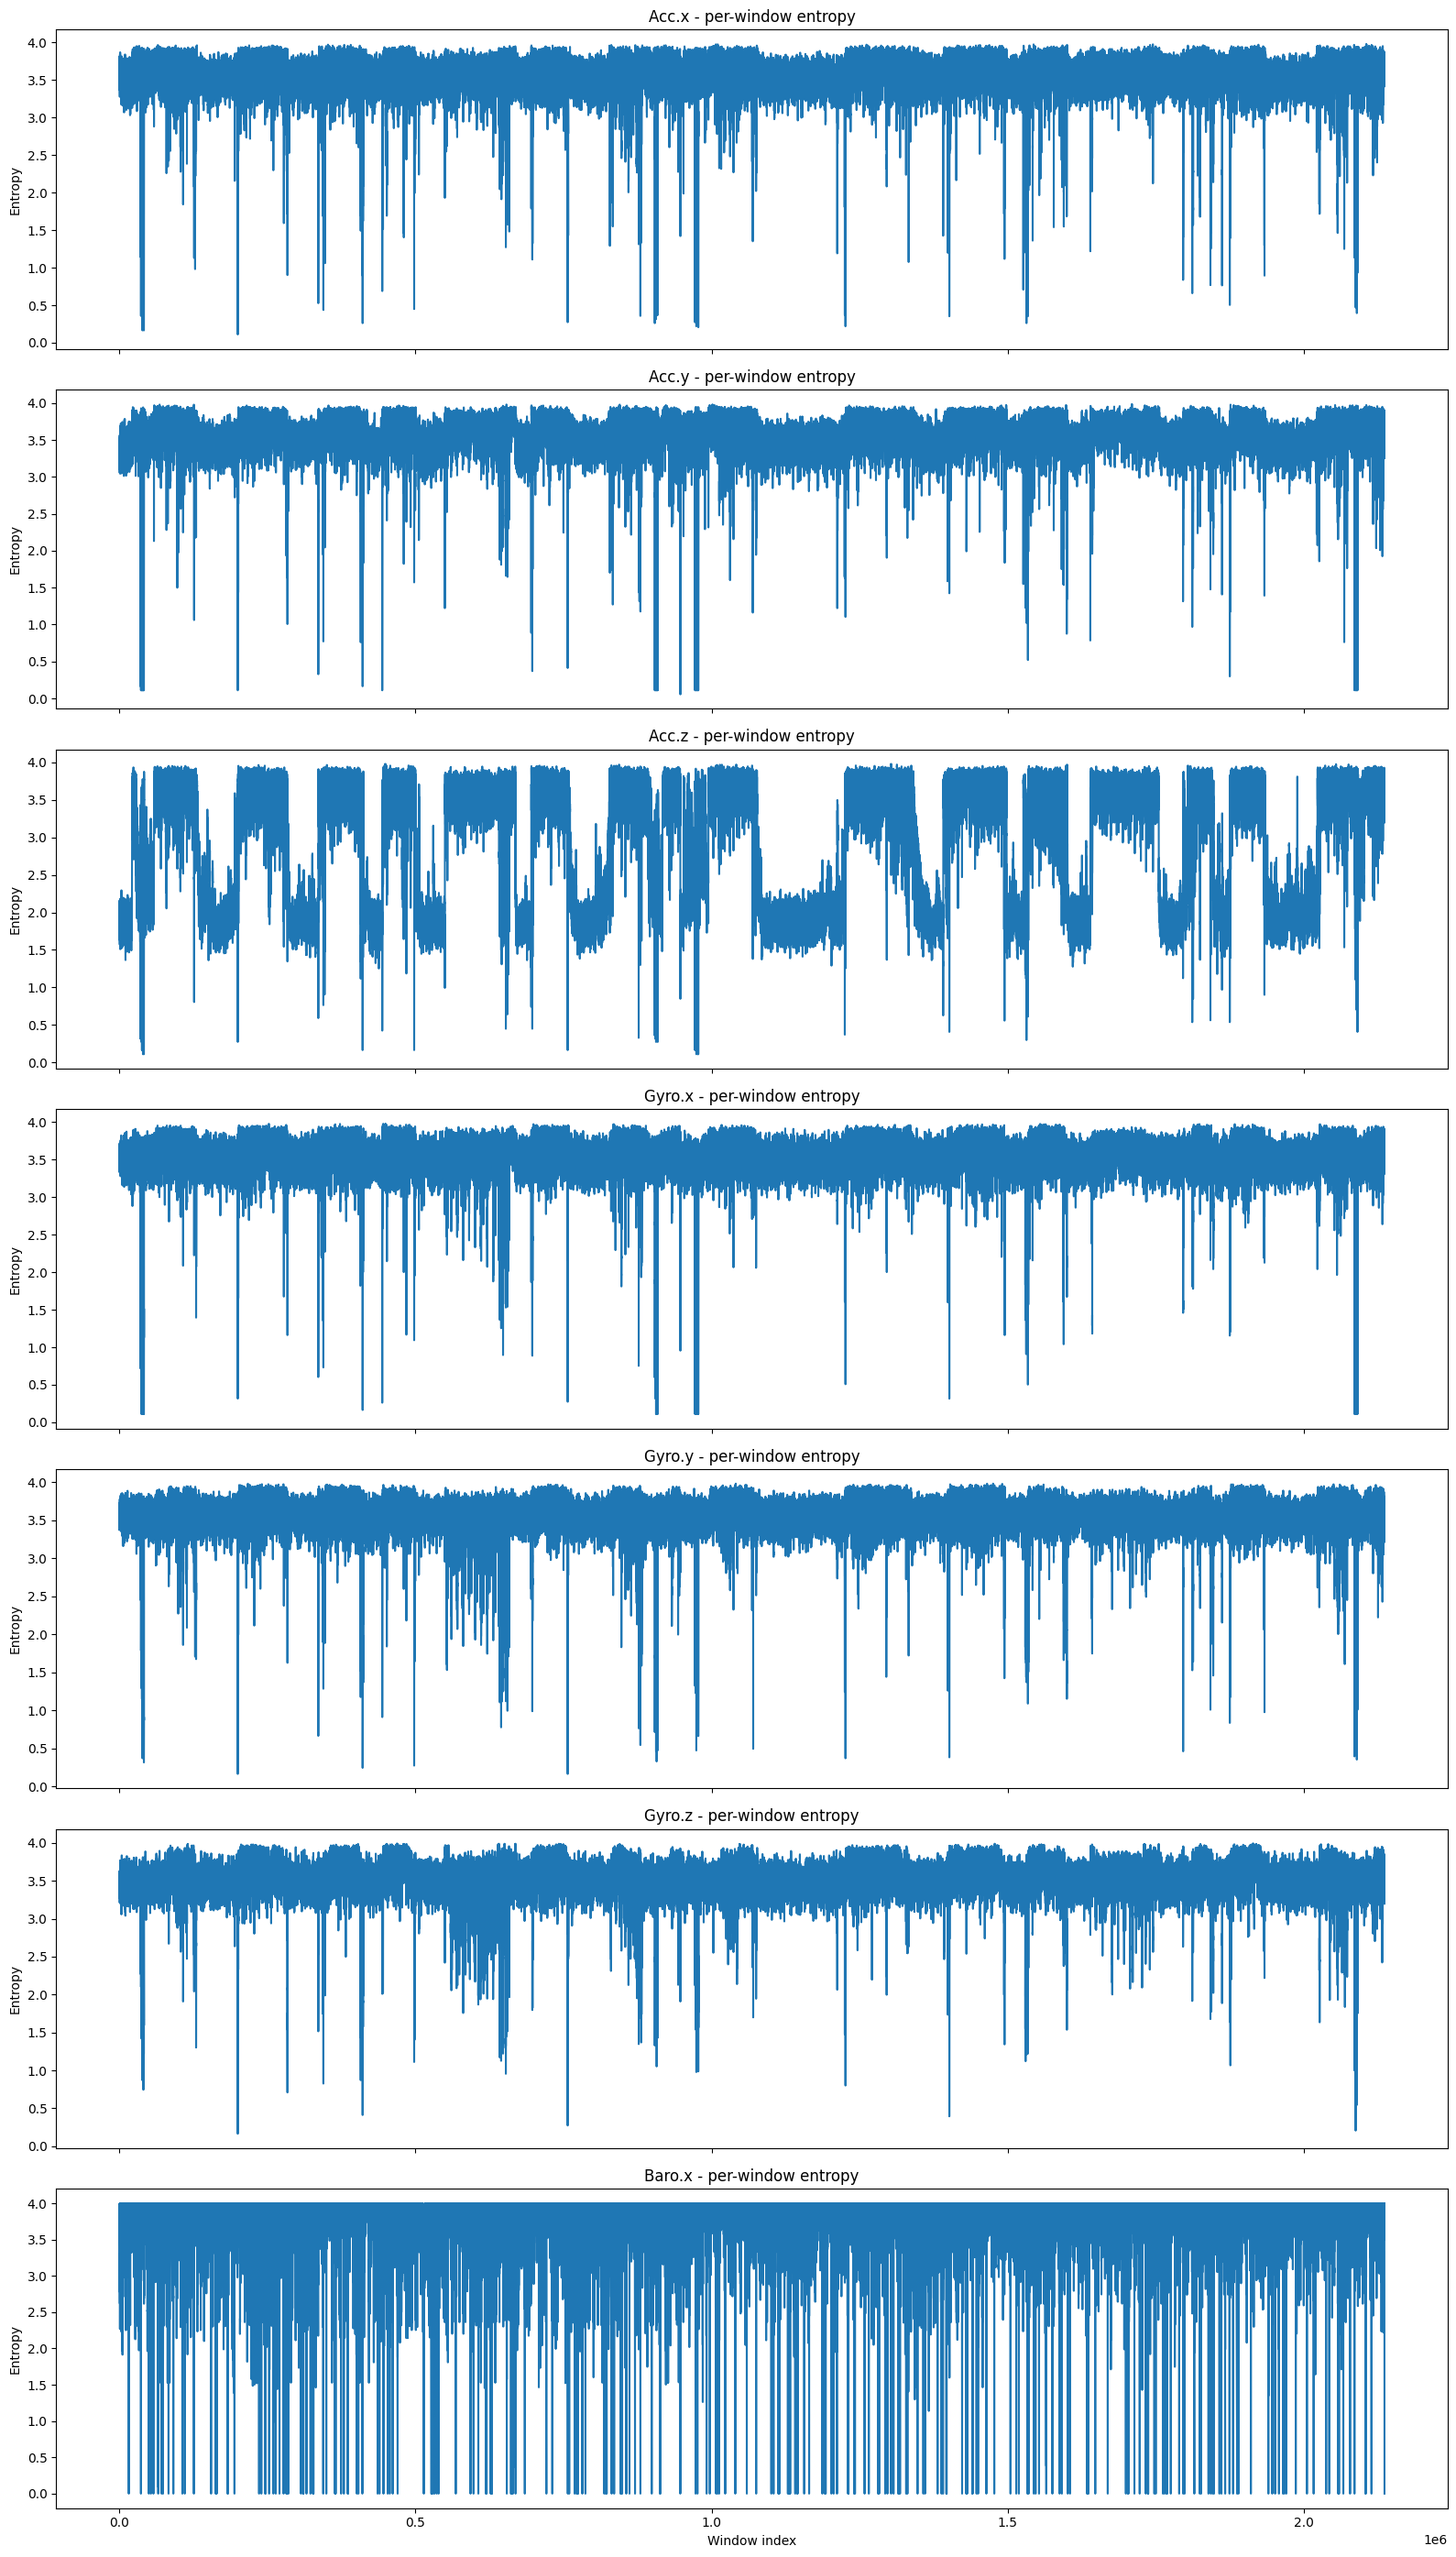

In [13]:
fig, axes = plt.subplots(len(sensor_names), 1, figsize=(16, 4 * len(sensor_names)), sharex=True)

for i, col in enumerate(sensor_names):
    axes[i].plot(window_entropy_df[col].values)
    axes[i].set_ylabel("Entropy")
    axes[i].set_title(f"{col} - per-window entropy")

axes[-1].set_xlabel("Window index")
plt.tight_layout()
plt.show()

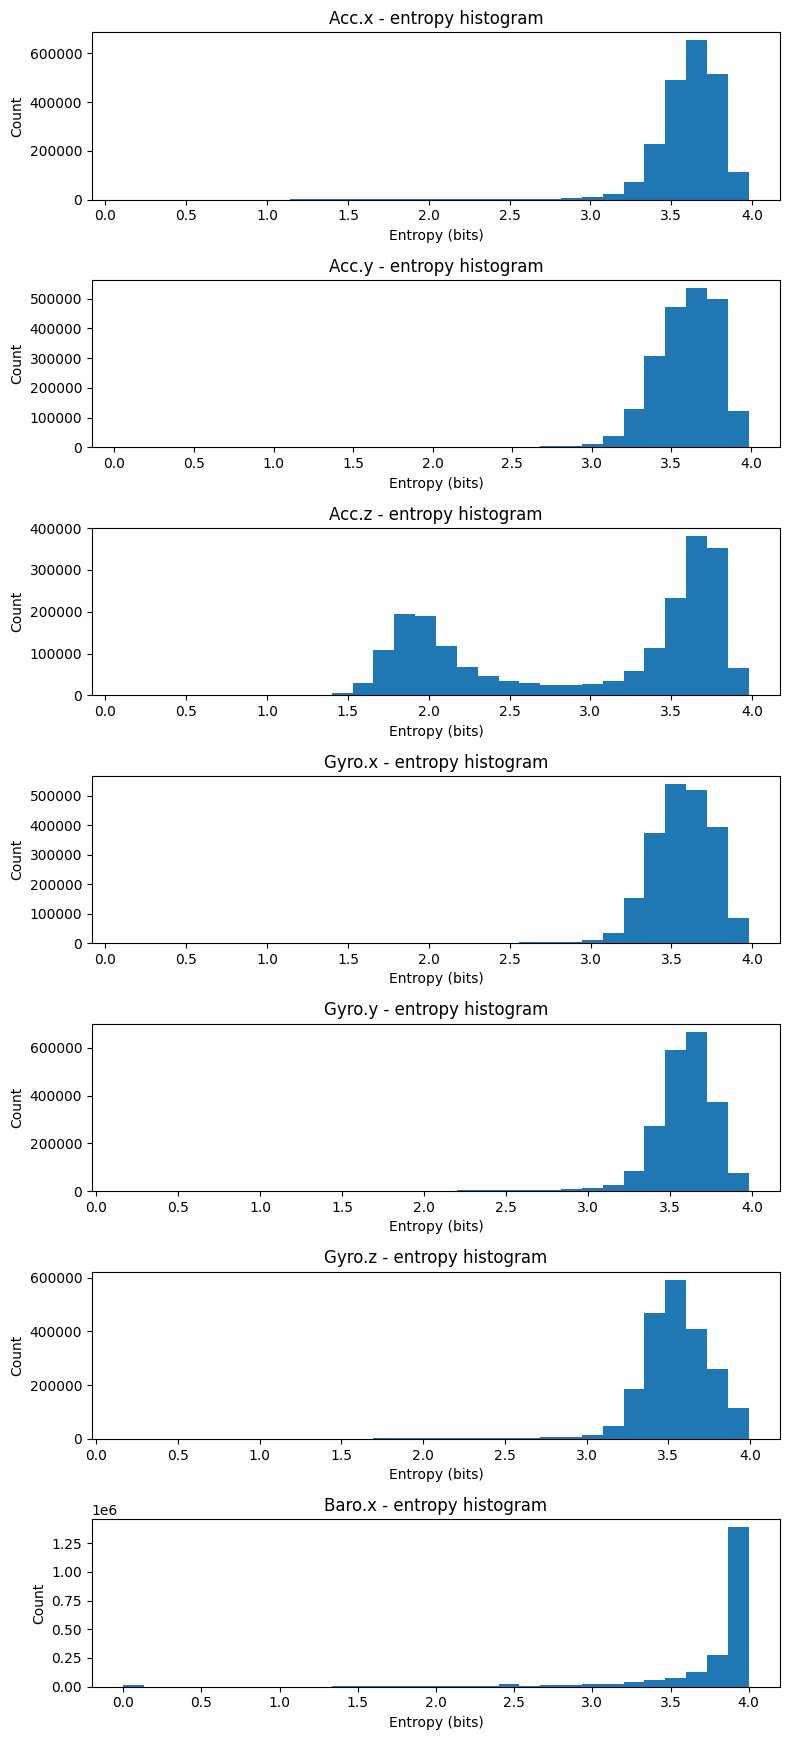

In [14]:
fig, axes = plt.subplots(len(sensor_names), 1, figsize=(8, 2.5 * len(sensor_names)))

for i, sensor in enumerate(sensor_names):
    axes[i].hist(window_entropy_df[sensor].values, bins=30)
    axes[i].set_title(f"{sensor} - entropy histogram")
    axes[i].set_xlabel("Entropy (bits)")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

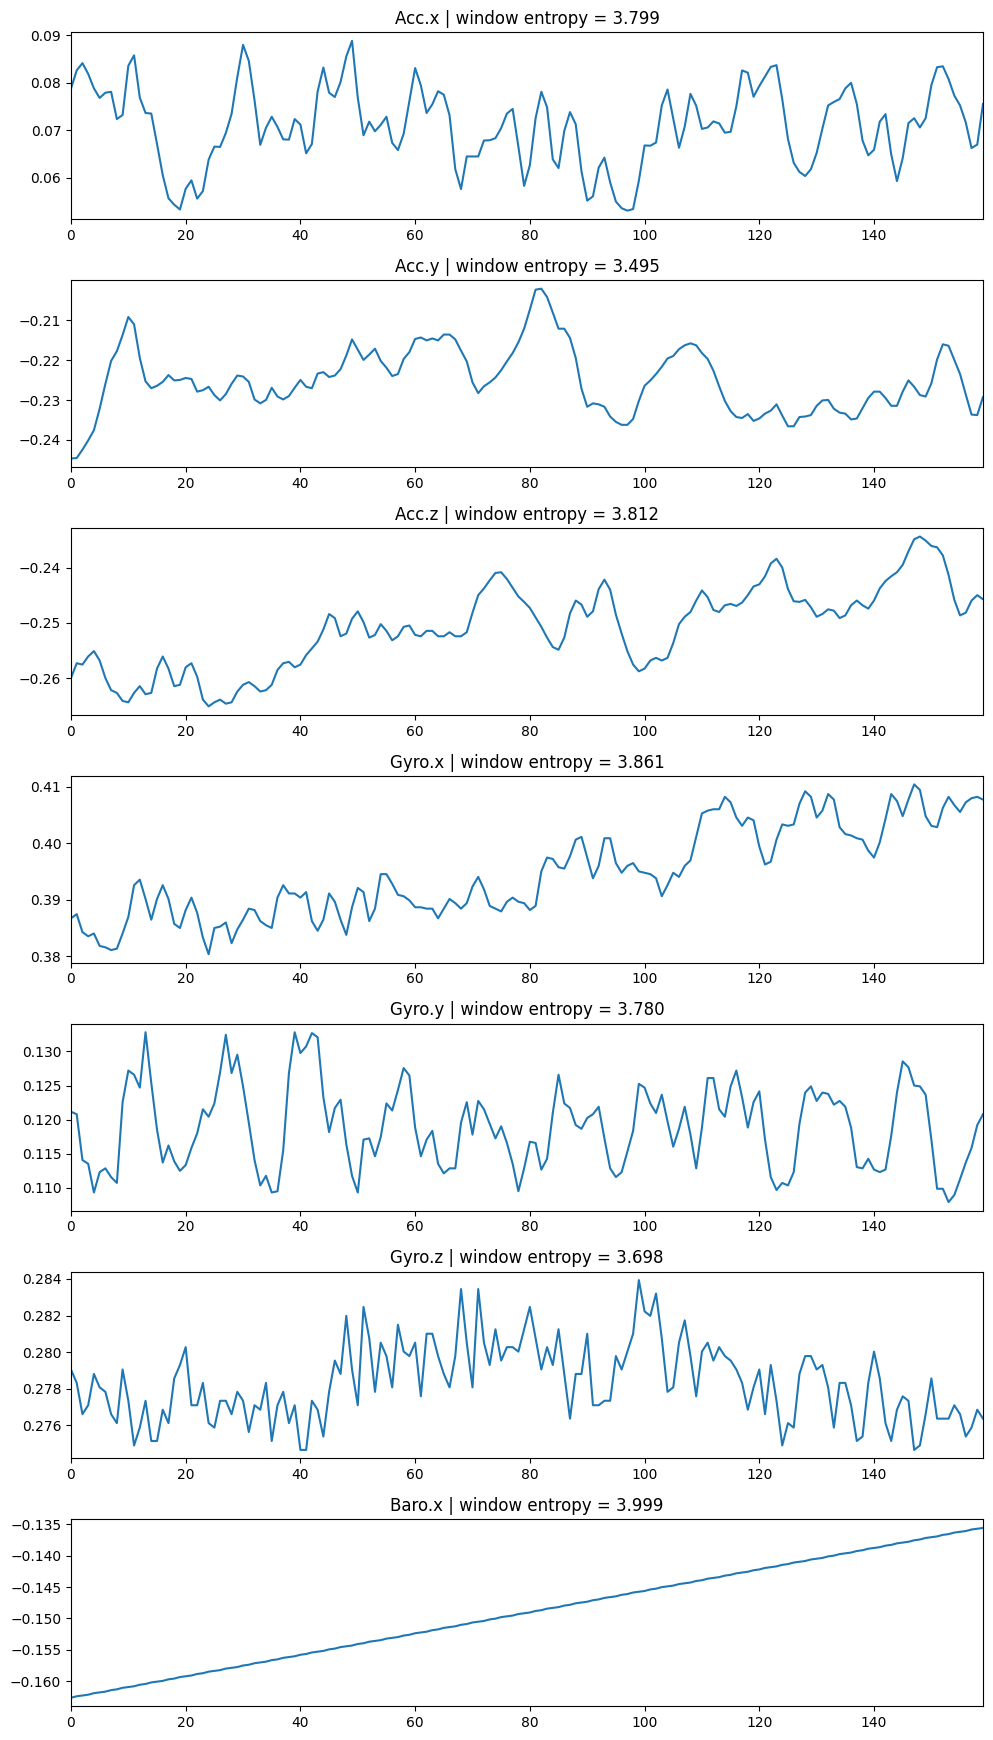

In [16]:
window_idx =2136220

fig, axes = plt.subplots(len(sensor_names), 1, figsize=(10, 2.5 * len(sensor_names)))

for j, sensor in enumerate(sensor_names):
    signal = X_sub[window_idx, j, :]
    ent = window_entropy_df.iloc[window_idx, j]

    axes[j].plot(signal)
    axes[j].set_title(f"{sensor} | window entropy = {ent:.3f}")
    axes[j].set_xlim(0, len(signal)-1)

plt.tight_layout()
plt.show()

In [18]:
threshold = 1.0

rows = []

for sensor in sensor_names:
    idx = np.where(window_entropy_df[sensor].values < threshold)[0]
    for i in idx:
        rows.append({
            "sensor": sensor,
            "window_index": int(i),
            "entropy": float(window_entropy_df.loc[i, sensor])
        })

low_entropy_df = pd.DataFrame(rows).sort_values(["sensor", "window_index"]).reset_index(drop=True)
low_entropy_df

,sensor,window_index,entropy
0,Acc.x,36403,0.625891
1,Acc.x,36404,0.652636
2,Acc.x,36405,0.693996
3,Acc.x,36406,0.357051
4,Acc.x,36407,0.394179
...,...,...,...
32120,Gyro.z,2089715,0.995185
32121,Gyro.z,2089720,0.544359
32122,Gyro.z,2089721,0.799555
32123,Gyro.z,2089722,0.840467
